In [41]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [42]:
#Importing the Dataset
df=pd.read_csv('suzuki_stock_data.csv')

In [43]:
# Checking the dataset content
df.head()

,Date,Close,High,Low,Open,Volume
0,1/5/2015,734.777649,747.170748,728.017776,745.634414,7380400
1,1/6/2015,707.943176,721.770191,707.021375,715.727274,11456000
2,1/7/2015,728.529968,732.319594,702.821966,705.587368,10361600
3,1/8/2015,750.448242,755.569358,733.650984,737.747876,10652000
4,1/9/2015,743.893433,757.413181,740.411073,755.672001,11038800


In [44]:
df.dtypes

Date       object
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

In [45]:
# Since the Date column is of object type, converting it to datetime formate and indexing it
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
print(df.index)


DatetimeIndex(['2015-01-05', '2015-01-06', '2015-01-07', '2015-01-08',
               '2015-01-09', '2015-01-13', '2015-01-14', '2015-01-15',
               '2015-01-16', '2015-01-19',
               ...
               '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-03',
               '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09',
               '2026-04-10', '2026-04-13'],
              dtype='datetime64[ns]', name='Date', length=2776, freq=None)


In [46]:
df.shape

(2776, 5)

In [47]:
#Checking for missing values
print(df.isnull().sum())

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [48]:
df.describe()

,Close,High,Low,Open,Volume
count,2776.000000,2776.000000,2776.000000,2776.000000,2.776000e+03
mean,1183.198690,1196.779190,1169.899434,1183.707651,7.829141e+06
std,384.300282,388.599162,380.043831,384.562347,4.685625e+06
min,535.432312,554.459460,509.059682,536.301001,0.000000e+00
25%,923.767731,931.743373,913.725426,923.811612,5.185975e+06
50%,1107.156006,1118.086278,1095.430134,1105.962436,6.859600e+06
75%,1373.967560,1384.815435,1364.048001,1378.044241,9.118200e+06
max,2421.062256,2442.295314,2407.236081,2426.000177,1.045424e+08


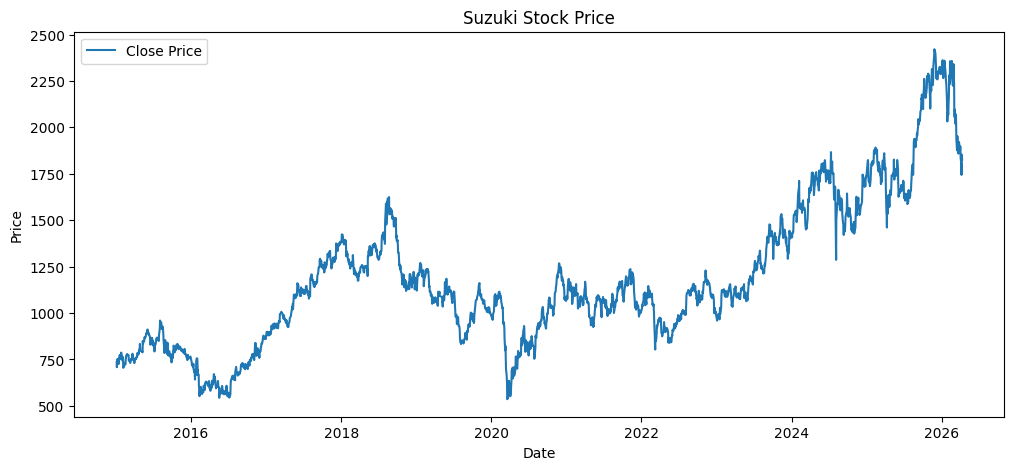

In [94]:
plt.figure(figsize = (12,5))
plt.plot(df['Close'], label = 'Close Price')
plt.title('Suzuki Stock Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [49]:
df['Target'] = (df['Close'].shift(-1) - df['Close'])

In [50]:
df['Decision'] = df['Target'].apply(lambda x: 1 if x > 0 else 0)

In [51]:
df.dropna(inplace = True)

In [52]:
df.isnull().sum()

Close       0
High        0
Low         0
Open        0
Volume      0
Target      0
Decision    0
dtype: int64

In [53]:
X = df.drop('Target', axis = 1)
X = X.drop('Decision', axis = 1)
y = df['Decision']

In [54]:
split = int(len(df) * 0.9)
X_train = X[:split]
y_train = y[:split]
X_test = X[split:]
y_test = y[split:]

In [55]:
# Fitting the model
model_rfr = RandomForestClassifier(
    n_estimators = 100, random_state = 42
)
model_rfr.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [56]:
y_pred = model_rfr.predict(X_test)

In [57]:
from sklearn.metrics import classification_report, confusion_matrix

In [58]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.51      0.73      0.60       135
           1       0.56      0.32      0.41       143

    accuracy                           0.52       278
   macro avg       0.53      0.53      0.50       278
weighted avg       0.53      0.52      0.50       278



In [59]:
df['Target']

Date
2015-01-05    -26.834473
2015-01-06     20.586792
2015-01-07     21.918274
2015-01-08     -6.554810
2015-01-09     -4.097046
                 ...    
2026-04-06    -59.000000
2026-04-07    109.000000
2026-04-08    -11.000000
2026-04-09    -16.000000
2026-04-10     -9.000000
Name: Target, Length: 2775, dtype: float64

In [61]:
X_test

,Close,High,Low,Open,Volume
Date,,,,,
2025-02-20,1880.141235,1947.358219,1821.145034,1839.037325,14340100
2025-02-21,1818.243530,1870.953250,1788.261855,1866.601071,9261100
2025-02-25,1778.106812,1798.900554,1772.787482,1793.097649,7608600
2025-02-26,1770.369507,1770.369507,1728.782023,1764.566602,5502000
2025-02-27,1813.891357,1813.891357,1766.984543,1774.238174,5363600
...,...,...,...,...,...
2026-04-06,1803.000000,1832.000000,1803.000000,1820.000000,9107400
2026-04-07,1744.000000,1748.500000,1670.000000,1683.000000,23078600
2026-04-08,1853.000000,1853.000000,1785.000000,1816.500000,16377400


In [60]:
y_pred

array([1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1])

In [68]:
import pandas as pd

features = {
    'Close': [1920.0, 1876.409668],
    'High': [1932.7, 1920.8],
    'Low': [1905.0, 1867.5],
    'Open': [1917.9, 1910.9],
    'Volume': [4828200, 9577400]
}

# Each row is one sample
features_df = pd.DataFrame(features)

predictions = model_rfr.predict(features_df)

for i, pred in enumerate(predictions):
    if pred == 1:
        print(f"Row {i}: The stock price is predicted to go up.")
    else:
        print(f"Row {i}: The stock price is predicted to go down.")


Row 0: The stock price is predicted to go down.
Row 1: The stock price is predicted to go down.


In [69]:
from xgboost import XGBClassifier

In [ ]:
model_xg = XGBClassifier(
    n_estimators = 300, max_depth = 6, random_state = 42)
model_xg.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [79]:
y_pred_xg = model_xg.predict(X_test)

In [80]:
print(classification_report(y_test, y_pred_xg))

              precision    recall  f1-score   support

           0       0.37      0.25      0.30       135
           1       0.46      0.60      0.52       143

    accuracy                           0.43       278
   macro avg       0.42      0.43      0.41       278
weighted avg       0.42      0.43      0.41       278



In [92]:

features = {
    'Close': [1921.344727, 1876.409668],
    'High': [1932.7, 1920.8],
    'Low': [1905.0, 1867.5],
    'Open': [1917.9, 1910.9],
    'Volume': [4828200, 9577400]
}

# Each row is one sample
features_df = pd.DataFrame(features)

predictions = model_xg.predict(features_df)

for i, pred in enumerate(predictions):
    if pred == 1:
        print(f"Row {i}: The stock price is predicted to go up.")
    else:
        print(f"Row {i}: The stock price is predicted to go down.")

Row 0: The stock price is predicted to go up.
Row 1: The stock price is predicted to go up.
